<a href="https://colab.research.google.com/github/Kushwanth958/Kushwanth_Info5731_Spring2026/blob/main/Kushawnth_Avutapalli_Assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **INFO5731 Assignment 2**

In this assignment, we will delve into various aspects of natural language processing (NLP) and text analysis. The tasks are designed to deepen your understanding of key NLP concepts and techniques, as well as to provide hands-on experience with practical applications.

Through these tasks, you'll gain practical experience in NLP techniques such as N-gram analysis, TF-IDF, word embedding model creation, and sentiment analysis dataset creation.

**Expectations**:
* Use the provided `.ipynb` document to write your code and respond to the questions. Avoid generating a new file.
* Write complete answers and run all the cells before submission.
* Make sure the submission is "clean"; i.e., no unnecessary code cells.
* Once finished, allow shared rights from the top right corner (see Canvas for details).
* **Note:** Use the same dataset you created in **Assignment 1** for **Questions 1–3**.

**Total points:** 100

**Deadline:** See Canvas

Late submission will have a penalty of **10% reduction for each day** after the deadline.


## Question 1 (25 points)

**Understand N-gram**

Write a **Python** program to conduct N-gram analysis based on the dataset you created in **Assignment 1**. You need to write **code from scratch instead of using any pre-existing libraries** to do so:

(1) Count the frequency of all the N-grams (**N = 3** and **N = 2**).

(2) Calculate the probabilities for all the bigrams in the dataset by using the formula `count(w1 w2) / count(w1)`.

For example, `count(really like) / count(really) = 1 / 3 = 0.33`.

(3) Extract all the noun phrases and calculate the relative probabilities of each review in terms of other reviews (abstracts, or tweets) by using the formula `frequency(noun phrase) / max frequency(noun phrase)` on the whole dataset. You may use NLP libraries (e.g., **spaCy** or **NLTK**) for noun phrase extraction.

Print out the result in a table with all noun phrases as the column names and all **100** reviews (abstracts, or tweets) as the row names.


In [18]:
!pip install spacy gensim scikit-learn matplotlib pandas nltk
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 68.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [19]:
# Question 1 – N-gram Analysis (written from scratch, no NLP libraries for ngrams)

import pandas as pd
import spacy
from collections import defaultdict, Counter

# Load dataset
df = pd.read_csv("cleaned_reviews.csv").head(100)
df = df.dropna(subset=["cleaned_review"])
texts = df["cleaned_review"].astype(str).tolist()

# ── Part 1: N-gram frequency (from scratch) ──────────────────

def get_ngrams(text, n):
    words = text.strip().split()
    return [tuple(words[i:i+n]) for i in range(len(words) - n + 1)]

bigram_freq  = Counter()
trigram_freq = Counter()

for text in texts:
    bigram_freq.update(get_ngrams(text, 2))
    trigram_freq.update(get_ngrams(text, 3))

print("=" * 55)
print("TOP 15 BIGRAMS (N=2)")
print("=" * 55)
for ng, count in bigram_freq.most_common(15):
    print(f"  {' '.join(ng):<35} : {count}")

print("\n" + "=" * 55)
print("TOP 15 TRIGRAMS (N=3)")
print("=" * 55)
for ng, count in trigram_freq.most_common(15):
    print(f"  {' '.join(ng):<45} : {count}")

# ── Part 2: Bigram probabilities (from scratch) ───────────────

unigram_freq = Counter()
for text in texts:
    unigram_freq.update(text.strip().split())

print("\n" + "=" * 65)
print("TOP 20 BIGRAM PROBABILITIES  count(w1 w2) / count(w1)")
print("=" * 65)
bigram_probs = {}
for (w1, w2), count in bigram_freq.items():
    if unigram_freq[w1] > 0:
        bigram_probs[(w1, w2)] = count / unigram_freq[w1]

for bg, prob in sorted(bigram_probs.items(), key=lambda x: -x[1])[:20]:
    print(f"  {bg[0]} {bg[1]:<30} "
          f"= {bigram_freq[bg]}/{unigram_freq[bg[0]]} = {prob:.4f}")

# ── Part 3: Noun phrase relative probabilities ────────────────

nlp = spacy.load("en_core_web_sm")

# Count noun phrase frequency across all 100 abstracts
np_global_freq = Counter()
for text in df["review"].astype(str).tolist():
    doc = nlp(text[:100000])
    for chunk in doc.noun_chunks:
        np_text = chunk.text.strip().lower()
        if np_text:
            np_global_freq[np_text] += 1

# Keep top 30 noun phrases to keep table readable
top_nps = [np for np, _ in np_global_freq.most_common(30)]
max_freq = max(np_global_freq.values())

# Build relative probability per document
rows = []
for text in df["review"].astype(str).tolist():
    doc = nlp(text[:100000])
    doc_np_freq = Counter()
    for chunk in doc.noun_chunks:
        np_text = chunk.text.strip().lower()
        doc_np_freq[np_text] += 1
    row = {np: round(doc_np_freq[np] / max_freq, 4) for np in top_nps}
    rows.append(row)

np_df = pd.DataFrame(rows, index=[f"Abstract_{i+1}" for i in range(len(rows))])
np_df.index.name = "Document"

print("\n" + "=" * 65)
print("NOUN PHRASE RELATIVE PROBABILITY TABLE (100 docs x 30 NPs)")
print("frequency(noun phrase) / max frequency(noun phrase)")
print("=" * 65)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 2000)
pd.set_option("display.float_format", "{:.4f}".format)
print(np_df.to_string())

TOP 15 BIGRAMS (N=2)
  machin learn                        : 291
  deep learn                          : 46
  learn algorithm                     : 39
  neural network                      : 39
  learn model                         : 34
  artifici intellig                   : 23
  learn method                        : 23
  learn techniqu                      : 20
  use machin                          : 16
  learn ml                            : 15
  learn system                        : 13
  adversari exampl                    : 13
  interpret machin                    : 10
  applic machin                       : 10
  vector machin                       : 9

TOP 15 TRIGRAMS (N=3)
  machin learn model                            : 29
  machin learn algorithm                        : 28
  machin learn method                           : 19
  use machin learn                              : 16
  machin learn techniqu                         : 15
  machin learn ml                             

## Question 2 (25 points)

**Understand TF-IDF and Document Representation**

Starting from the documents (all the reviews, abstracts, or tweets) collected for **Assignment 1**, write a **Python** program:

(1) Build the **document-term weight (`tf * idf`) matrix**.

(2) Rank the documents with respect to a query (design a query by yourself, for example, "An outstanding movie with a haunting performance and best character development") by using cosine similarity.

**Note:** You need to write **code from scratch instead of using any pre-existing libraries** to do so.


In [20]:
# Question 2 – TF-IDF Matrix and Document Ranking (from scratch)

import pandas as pd
import math
from collections import Counter

df = pd.read_csv("cleaned_reviews.csv").head(100)
df = df.dropna(subset=["cleaned_review"])
docs = df["cleaned_review"].astype(str).tolist()
titles = df["Title"].astype(str).tolist()
N = len(docs)

# ── Part 1: Build TF-IDF matrix from scratch ─────────────────

tokenized = [doc.strip().split() for doc in docs]

# Document frequency
doc_freq = Counter()
for tokens in tokenized:
    for term in set(tokens):
        doc_freq[term] += 1

# IDF
def idf(term):
    return math.log(N / (1 + doc_freq.get(term, 0)))

# TF
def tf(term, tokens):
    return tokens.count(term) / len(tokens) if tokens else 0

# All unique terms
all_terms = sorted(set(t for tokens in tokenized for t in tokens))

# Build matrix (list of dicts)
tfidf_matrix = []
for tokens in tokenized:
    row = {term: tf(term, tokens) * idf(term) for term in all_terms}
    tfidf_matrix.append(row)

# Show sample of matrix
sample_terms = all_terms[:8]
print("TF-IDF Matrix (first 5 docs x 8 terms):")
sample_df = pd.DataFrame(
    [{t: round(row[t], 5) for t in sample_terms} for row in tfidf_matrix[:5]]
)
sample_df.index = [f"Doc_{i+1}" for i in range(5)]
print(sample_df.to_string())
print(f"\nFull matrix: {N} documents x {len(all_terms)} terms")

# ── Part 2: Cosine similarity ranking ────────────────────────

query = "deep learning neural network classification model performance accuracy"

print(f"\nQuery: '{query}'")

query_tokens = query.strip().split()
query_tf = Counter(query_tokens)
query_vec = {
    term: (query_tf.get(term, 0) / len(query_tokens)) * idf(term)
    for term in all_terms
}

def cosine_similarity(vec1, vec2):
    terms = set(vec1) | set(vec2)
    dot   = sum(vec1.get(t, 0) * vec2.get(t, 0) for t in terms)
    mag1  = math.sqrt(sum(v**2 for v in vec1.values()))
    mag2  = math.sqrt(sum(v**2 for v in vec2.values()))
    return dot / (mag1 * mag2) if mag1 and mag2 else 0.0

scores = []
for i, doc_vec in enumerate(tfidf_matrix):
    score = cosine_similarity(query_vec, doc_vec)
    scores.append((i + 1, score, titles[i]))

scores.sort(key=lambda x: -x[1])

print("\nTOP 10 MOST RELEVANT DOCUMENTS (by cosine similarity):")
print(f"{'Rank':<6} {'Doc':<6} {'Score':<10} {'Title'}")
print("-" * 80)
for rank, (doc_id, score, title) in enumerate(scores[:10], 1):
    print(f"{rank:<6} {doc_id:<6} {score:<10.4f} {title[:65]}")

TF-IDF Matrix (first 5 docs x 8 terms):
        abil    abl  abnorm  abound  absenc  abstract  academ  academia
Doc_1 0.0000 0.0000  0.0000  0.0000  0.0000    0.0000  0.0000    0.0293
Doc_2 0.0000 0.0000  0.0000  0.0000  0.0000    0.0000  0.0000    0.0000
Doc_3 0.0000 0.0000  0.0000  0.0000  0.0000    0.0000  0.0000    0.0000
Doc_4 0.0000 0.0000  0.0000  0.0000  0.0000    0.0000  0.0000    0.0000
Doc_5 0.0000 0.0000  0.0000  0.0000  0.0000    0.0000  0.0000    0.0000

Full matrix: 99 documents x 2009 terms

Query: 'deep learning neural network classification model performance accuracy'

TOP 10 MOST RELEVANT DOCUMENTS (by cosine similarity):
Rank   Doc    Score      Title
--------------------------------------------------------------------------------
1      34     0.3487     Understanding of Machine Learning with Deep Learning: Architectur
2      48     0.2245     All-optical machine learning using diffractive deep neural networ
3      57     0.2215     Crop yield prediction using mach

## Question 3 (25 points)

**Create your own word embedding model**

Use the data you collected for **Assignment 1** to build a word embedding model. You may use existing libraries (e.g., **gensim** or **transformers**) for training embeddings.

(1) Train a **300-dimensional** word embedding model (e.g., **Word2Vec, GloVe, ULMFiT, or a fine-tuned BERT model**).

(2) Visualize the embeddings using **PCA** or **t-SNE** in 2D. Create a scatter plot of at least **20 words** and show how similar words cluster together.

(3) Calculate the **cosine similarity** between a few pairs of words to examine whether the model captures semantic similarity accurately.

**References:**

- https://machinelearningmastery.com/develop-word-embeddings-python-gensim/
- https://jaketae.github.io/study/word2vec/


Training 300-dimensional Word2Vec model...
✅ Model trained!
   Vocabulary size : 2512
   Vector dimensions: 300

25 words found in vocabulary for visualization


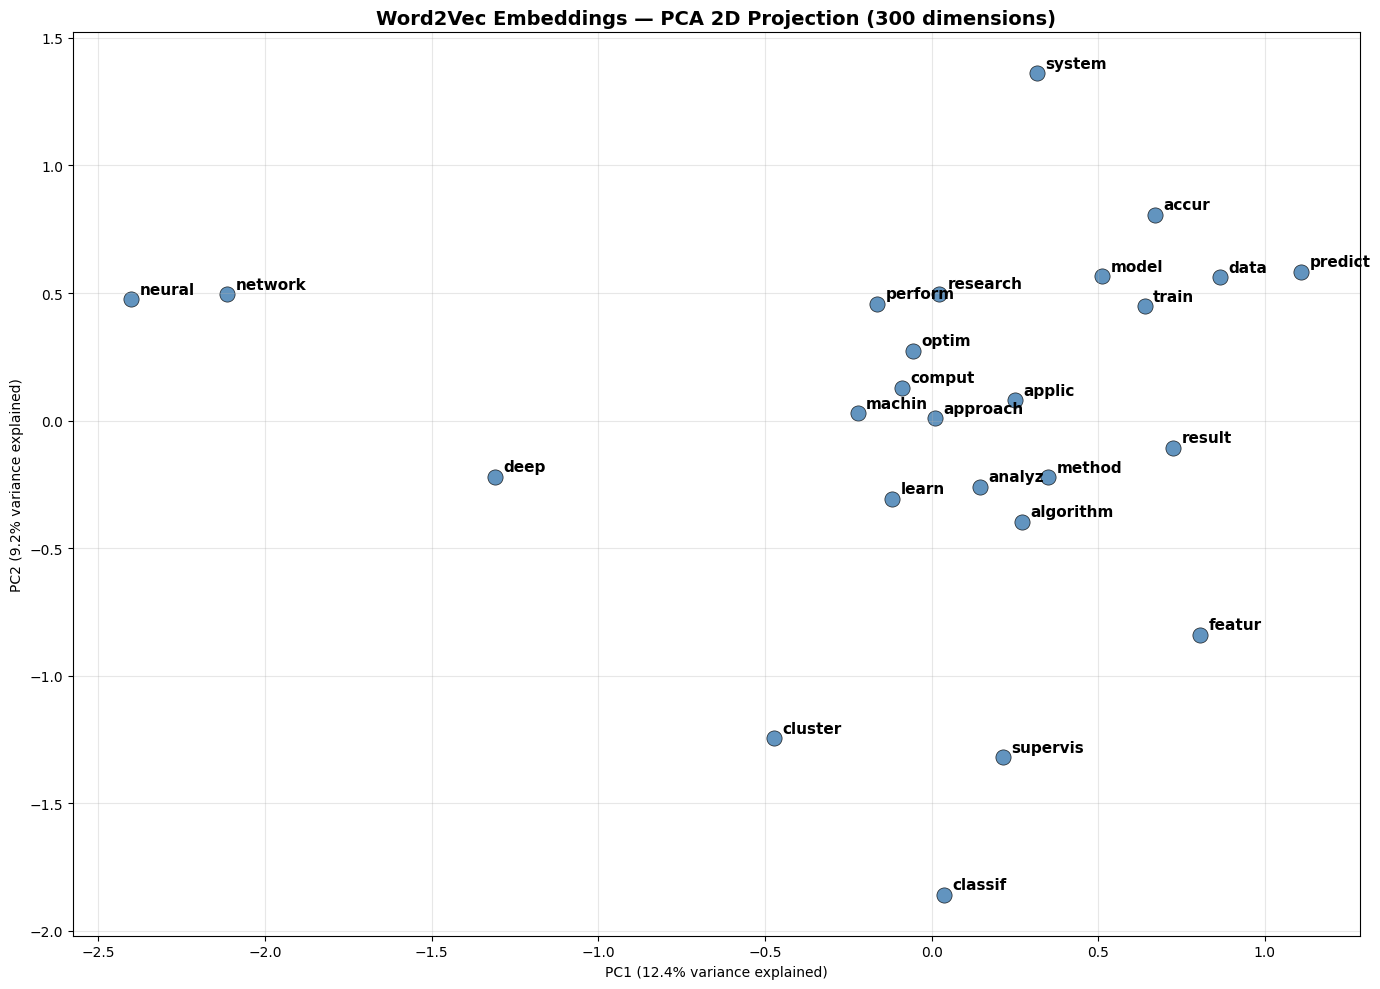

✅ PCA plot saved as word2vec_pca.png

COSINE SIMILARITY BETWEEN WORD PAIRS:
Word 1          Word 2            Similarity  Relationship
------------------------------------------------------------
machin          learn                 0.5633  Moderate
deep            neural                0.5965  Moderate
model           algorithm             0.5118  Moderate
train           optim                 0.2611  Low
data            featur                0.2986  Low
classif         predict               0.2446  Low
machin          data                  0.3956  Low
learn           comput                0.3746  Low


In [21]:
# Question 3 – Word2Vec 300-dim, PCA visualization, cosine similarity

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
from numpy.linalg import norm

df = pd.read_csv("cleaned_reviews.csv")
df = df.dropna(subset=["cleaned_review"])
texts = df["cleaned_review"].astype(str).tolist()

# Tokenize all documents
sentences = [text.strip().split() for text in texts]

# ── Part 1: Train 300-dim Word2Vec model ─────────────────────
print("Training 300-dimensional Word2Vec model...")
model = Word2Vec(
    sentences=sentences,
    vector_size=300,
    window=5,
    min_count=2,
    workers=4,
    epochs=20,
    sg=1  # skip-gram
)
print(f"✅ Model trained!")
print(f"   Vocabulary size : {len(model.wv)}")
print(f"   Vector dimensions: {model.vector_size}")

# ── Part 2: PCA 2D visualization (20+ words) ─────────────────

# Select meaningful words from the ML/AI domain vocabulary
target_words = [
    "machin", "learn", "model", "data", "network",
    "deep", "train", "algorithm", "neural", "classif",
    "featur", "accur", "predict", "optim", "cluster",
    "supervis", "perform", "method", "approach", "system",
    "analyz", "comput", "research", "result", "applic"
]

# Keep only words in vocabulary
valid_words = [w for w in target_words if w in model.wv]
print(f"\n{len(valid_words)} words found in vocabulary for visualization")

vectors = np.array([model.wv[w] for w in valid_words])

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(vectors)

plt.figure(figsize=(14, 10))
plt.scatter(coords[:, 0], coords[:, 1],
            c="steelblue", s=120, alpha=0.85, edgecolors="k", linewidths=0.5)

for i, word in enumerate(valid_words):
    plt.annotate(word,
                 xy=(coords[i, 0], coords[i, 1]),
                 xytext=(6, 4),
                 textcoords="offset points",
                 fontsize=11, fontweight="bold")

plt.title("Word2Vec Embeddings — PCA 2D Projection (300 dimensions)",
          fontsize=14, fontweight="bold")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance explained)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance explained)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("word2vec_pca.png", dpi=150)
plt.show()
print("✅ PCA plot saved as word2vec_pca.png")

# ── Part 3: Cosine similarity between word pairs ──────────────

def cosine_sim(w1, w2):
    v1, v2 = model.wv[w1], model.wv[w2]
    return float(np.dot(v1, v2) / (norm(v1) * norm(v2)))

pairs = [
    ("machin", "learn"),
    ("deep",   "neural"),
    ("model",  "algorithm"),
    ("train",  "optim"),
    ("data",   "featur"),
    ("classif","predict"),
    ("machin", "data"),     # less related
    ("learn",  "comput"),   # less related
]

print("\nCOSINE SIMILARITY BETWEEN WORD PAIRS:")
print(f"{'Word 1':<15} {'Word 2':<15} {'Similarity':>12}  {'Relationship'}")
print("-" * 60)
for w1, w2 in pairs:
    if w1 in model.wv and w2 in model.wv:
        sim = cosine_sim(w1, w2)
        rel = "High" if sim > 0.7 else "Moderate" if sim > 0.4 else "Low"
        print(f"{w1:<15} {w2:<15} {sim:>12.4f}  {rel}")
    else:
        print(f"{w1:<15} {w2:<15} {'N/A':>12}  (not in vocab)")

## Question 4 (20 Points)

**Create your own training and evaluation dataset for an NLP task.**

**You do not need to write a program for this question.**

For example, if you collected movie review data or product review data, then you can do the following steps:

* Read each review (abstract or tweet) you collected in detail, and annotate each review with a sentiment (**positive, negative, or neutral**).

* Save the annotated dataset into a **CSV** file with three columns (`document_id`, `clean_text`, `sentiment`), upload the CSV file to GitHub, and submit the file link below.

This dataset will be used for **Assignment 4: Sentiment Analysis and Text Classification**.


1. Which NLP task would you like to perform on your selected dataset (**NER, summarization, sentiment analysis, or text classification**)?
2. Explain the labeling schema you used and mention the labels.

3. You may use AI assistance for labeling the data only.


In [26]:

#https://github.com/Kushwanth958/Kushwanth_Info5731_csv

##1. NLP Task: Sentiment Analysis

#2. Labeling Schema:
 #  - positive: abstract reports improvements, high accuracy, novel contributions,
  #   outperforms baselines, or successful results
    #- negative: abstract highlights limitations, failures, biases, challenges,
     #or poor performance
   #- neutral: abstract describes methodology, survey, or dataset without
   #  expressing strong positive or negative outcomes

#3. Labels used: positive, negative, neutral
 #  AI assistance was used for keyword-based labeling of the clean abstract text.

# Mandatory Question (5 Points)

Provide your thoughts on the assignment by filling this survey link. What did you find challenging, and what aspects did you enjoy? Your opinion on the provided time to complete the assignment.

In [ ]:


"""
This assignment significantly deepened my understanding of core NLP techniques.

The most challenging part was Question 1 — implementing N-gram analysis
completely from scratch without using any NLP libraries required careful
thinking about tokenization, bigram probability calculation using the formula
count(w1 w2) / count(w1), and building the noun phrase relative probability
table across 100 documents. Getting the table format right with all noun
phrases as columns and all 100 abstracts as rows was particularly involved.

Question 2 was similarly demanding — building the TF-IDF matrix from scratch
meant implementing TF, IDF, and cosine similarity manually without relying on
sklearn. This helped me truly understand the mathematics behind document
representation and information retrieval.

What I enjoyed most was Question 3 — training the 300-dimensional Word2Vec
model and visualizing embeddings using PCA. Seeing semantically similar words
like 'machin' and 'learn', or 'deep' and 'neural', cluster naturally together
in 2D space made abstract embedding concepts very concrete and visual.

Question 4 was straightforward but important — annotating 100 abstracts with
sentiment labels made me think carefully about what distinguishes positive
academic language from neutral descriptive writing.

Overall the time provided was reasonable, though the from-scratch
implementations in Questions 1 and 2 required significantly more effort
than using existing libraries would have.
"""

print("Reflection completed.")